# Session 10 Lab - Anonymization in Practice
### Responsible Data Management: FAIR Principles & Privacy
**Research Methods & Scientific Integrity in AI** · UNMSM Doctoral Program in Deep Technologies
Instructor: Dr. Loveleen Gaur

---

This notebook makes the two anonymization ideas from today's session **runnable**:

1. **k-anonymity** - hide a person inside a crowd of at least *k* look-alikes, and see where it still leaks.
2. **Differential privacy** - answer a query while provably masking any single person's contribution.

**How to use it:** run every cell top to bottom (in Colab: *Runtime -> Run all*). Read the short text above each code block, run it, and do the exercises at the end of each part.

> **Note on the data.** The patient table below is **synthetic** - invented for teaching. It contains no real people. That is deliberate: you should never practise re-identification on real personal data.


In [1]:
# Setup - standard scientific Python (all pre-installed in Google Colab)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
print("Ready. pandas", pd.__version__, "| numpy", np.__version__)

Ready. pandas 3.0.3 | numpy 2.4.6


## Part 1 - k-anonymity

Below is a small hospital release. The direct identifier (the patient's name) has already been removed. The question the session asked: **is that enough?**

The columns **ZIP, Age, Sex** are *quasi-identifiers* - harmless alone, but in combination they can point to one person, especially when linked to an outside source (a voter roll, a social profile). **Diagnosis** is the *sensitive* attribute we are trying to protect.

In [2]:
raw = pd.DataFrame({
    "ZIP":       ["41075", "41075", "41076", "41099", "41099", "41099"],
    "Age":       [29, 22, 27, 43, 52, 47],
    "Sex":       ["F", "F", "M", "M", "F", "M"],
    "Diagnosis": ["Flu", "Flu", "Heart disease", "Diabetes", "Flu", "Diabetes"],
})

QUASI_IDENTIFIERS = ["ZIP", "Age", "Sex"]
SENSITIVE = "Diagnosis"
raw

     ZIP  Age Sex      Diagnosis
0  41075   29   F            Flu
1  41075   22   F            Flu
2  41076   27   M  Heart disease
3  41099   43   M       Diabetes
4  41099   52   F            Flu
5  41099   47   M       Diabetes

### Measuring k

A dataset is **k-anonymous** if every combination of quasi-identifiers appears **at least k times**. So *k* is simply the size of the **smallest** quasi-identifier group. If any combination is unique, k = 1 and that person stands alone.

In [3]:
def k_anonymity(df, quasi_identifiers):
    """Return k = the size of the smallest quasi-identifier group."""
    group_sizes = df.groupby(quasi_identifiers).size()
    return int(group_sizes.min())

print("Group sizes for the raw table:")
print(raw.groupby(QUASI_IDENTIFIERS).size().to_string())
print()
print("k for the raw table =", k_anonymity(raw, QUASI_IDENTIFIERS))

Group sizes for the raw table:
ZIP    Age  Sex
41075  22   F      1
       29   F      1
41076  27   M      1
41099  43   M      1
       47   M      1
       52   F      1

k for the raw table = 1


**k = 1.** Every row is a unique ZIP-Age-Sex combination, so removing the name protected no one. A single link to an outside dataset re-identifies each patient. This is exactly the Netflix attack from the session, in miniature.

### Generalizing until the crowd forms

We reduce precision until look-alikes appear: truncate the ZIP, put age into 20-year bands, and suppress sex. We keep the sensitive column untouched.

In [4]:
def age_band(age, width=20):
    low = (age // width) * width
    return f"{low}-{low + width - 1}"

generalized = raw.copy()
generalized["ZIP"] = generalized["ZIP"].str[:3] + "**"   # 41075 -> 410**
generalized["Age"] = generalized["Age"].apply(age_band)  # 29 -> 20-39
generalized["Sex"] = "*"                                 # suppressed

generalized

     ZIP    Age Sex      Diagnosis
0  410**  20-39   *            Flu
1  410**  20-39   *            Flu
2  410**  20-39   *  Heart disease
3  410**  40-59   *       Diabetes
4  410**  40-59   *            Flu
5  410**  40-59   *       Diabetes

In [5]:
print("Group sizes after generalizing:")
print(generalized.groupby(QUASI_IDENTIFIERS).size().to_string())
print()
print("k after generalizing =", k_anonymity(generalized, QUASI_IDENTIFIERS))

Group sizes after generalizing:
ZIP    Age    Sex
410**  20-39  *      3
       40-59  *      3

k after generalizing = 3


Our **target** in the session was k >= 2. This generalization actually reaches **k = 3** - each group has three members. Generalization often overshoots the target, and the cost is precision: we can no longer tell a 29-year-old from a 22-year-old.

### Where k-anonymity still leaks

k-anonymity hides *identity*, but says nothing about the *sensitive value*. If everyone in a group shares the same diagnosis, we learn it anyway without ever identifying the individual. **l-diversity** asks each group to contain at least *l* distinct sensitive values.

In [6]:
# l-diversity: how many DISTINCT diagnoses does each quasi-identifier group contain?
l_diversity = generalized.groupby(QUASI_IDENTIFIERS)[SENSITIVE].nunique()
print("Distinct diagnoses per group (l):")
print(l_diversity.to_string())
print()

# Look closer at the 40-59 group - the distribution, not just the count
older = generalized[generalized["Age"] == "40-59"]
print("Diagnosis distribution in the 40-59 group:")
print(older[SENSITIVE].value_counts().to_string())

Distinct diagnoses per group (l):
ZIP    Age    Sex
410**  20-39  *      2
       40-59  *      2

Diagnosis distribution in the 40-59 group:
Diagnosis
Diabetes    2
Flu         1


Both groups clear a bare **l = 2** (two distinct diagnoses each). But look at the distribution: the 40-59 group is **2/3 Diabetes**. Knowing only that someone falls in that group already makes Diabetes the odds-on guess. That skew is what **t-closeness** targets - it asks each group's distribution of sensitive values to stay close to the distribution in the whole dataset.

**The takeaway:** k-anonymity, l-diversity and t-closeness each close a *different* door. Reaching k >= 2 is necessary, not sufficient.

### Exercises - Part 1

1. Change `age_band(width=20)` to `width=10`. What is the new k? Why did protection get weaker?
2. Instead of suppressing Sex entirely, keep it and truncate ZIP to `41***`. Does the table still reach k >= 2?
3. Write a function `is_l_diverse(df, quasi_identifiers, sensitive, l)` that returns `True` only if **every** group has at least `l` distinct sensitive values. Test it with l = 2 and l = 3.

In [7]:
# Completed exercises - Part 1

# 1) Narrower 10-year age bands create unique groups and reduce protection.
age10 = raw.copy()
age10["ZIP"] = age10["ZIP"].str[:3] + "**"
age10["Age"] = age10["Age"].apply(lambda age: age_band(age, width=10))
age10["Sex"] = "*"
print("Exercise 1 - k with 10-year age bands =", k_anonymity(age10, QUASI_IDENTIFIERS))

# 2) Keeping Sex while generalizing ZIP still leaves unique combinations.
keep_sex = raw.copy()
keep_sex["ZIP"] = keep_sex["ZIP"].str[:2] + "***"
keep_sex["Age"] = keep_sex["Age"].apply(age_band)
print("Exercise 2 - k with Sex retained and ZIP 41*** =", k_anonymity(keep_sex, QUASI_IDENTIFIERS))

# 3) Every equivalence class must contain at least l sensitive values.
def is_l_diverse(df, quasi_identifiers, sensitive, l):
    distinct = df.groupby(quasi_identifiers)[sensitive].nunique()
    return bool((distinct >= l).all())

print("Exercise 3 - l=2:", is_l_diverse(generalized, QUASI_IDENTIFIERS, SENSITIVE, 2))
print("Exercise 3 - l=3:", is_l_diverse(generalized, QUASI_IDENTIFIERS, SENSITIVE, 3))


Exercise 1 - k with 10-year age bands = 1
Exercise 2 - k with Sex retained and ZIP 41*** = 1
Exercise 3 - l=2: True
Exercise 3 - l=3: False


## Part 2 - Differential privacy

k-anonymity protects a *released table*. **Differential privacy (DP)** protects the *answer to a query*. Its promise: the result looks almost the same whether or not any one person is in the data, so no single person's participation can be inferred - and that guarantee holds no matter what outside knowledge an attacker has.

We will answer a sensitive count - *"How many people in this dataset have a given condition?"* - using the **Laplace mechanism**: add random noise scaled to `sensitivity / epsilon`.

- **sensitivity** = the most the true answer can change if one person is added or removed. For a count, that is **1**.
- **epsilon (ε)** = the *privacy budget*. Small ε = more noise = stronger privacy, less accuracy. Large ε = the reverse.

In [8]:
rng = np.random.default_rng(42)   # fixed seed so your run matches the notes

TRUE_COUNT  = 42     # the real answer we want to protect
SENSITIVITY = 1.0    # a count changes by at most 1 when one person joins/leaves

def dp_count(true_value, epsilon, n_draws=20000):
    """Release a noisy count via the Laplace mechanism. Returns many draws so
    we can see the spread of possible released answers."""
    scale = SENSITIVITY / epsilon
    return true_value + rng.laplace(loc=0.0, scale=scale, size=n_draws)

for eps in [0.1, 0.5, 1.0, 10.0]:
    draws = dp_count(TRUE_COUNT, eps)
    mean, sd = draws.mean(), draws.std()
    print(f"epsilon = {eps:>4}  ->  Laplace scale = {SENSITIVITY/eps:>5.2f} | "
          f"released mean {mean:5.1f}, +/-1 SD spans {mean-sd:4.0f} to {mean+sd:4.0f}")

epsilon =  0.1  ->  Laplace scale = 10.00 | released mean  42.0, +/-1 SD spans   28 to   56
epsilon =  0.5  ->  Laplace scale =  2.00 | released mean  42.0, +/-1 SD spans   39 to   45
epsilon =  1.0  ->  Laplace scale =  1.00 | released mean  42.0, +/-1 SD spans   41 to   43
epsilon = 10.0  ->  Laplace scale =  0.10 | released mean  42.0, +/-1 SD spans   42 to   42


Read the ±1 SD spans against the slide you saw in class:

- **ε = 0.1** (strong privacy): roughly **28 to 56** - the noise is large, the individual is well hidden, the count is rough.
- **ε = 1.0** (balanced): a tight band near 41 to 43.
- **ε = 10** (weak privacy): essentially the true 42 - accurate, but little protection.

### See the trade-off

<notebook>:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


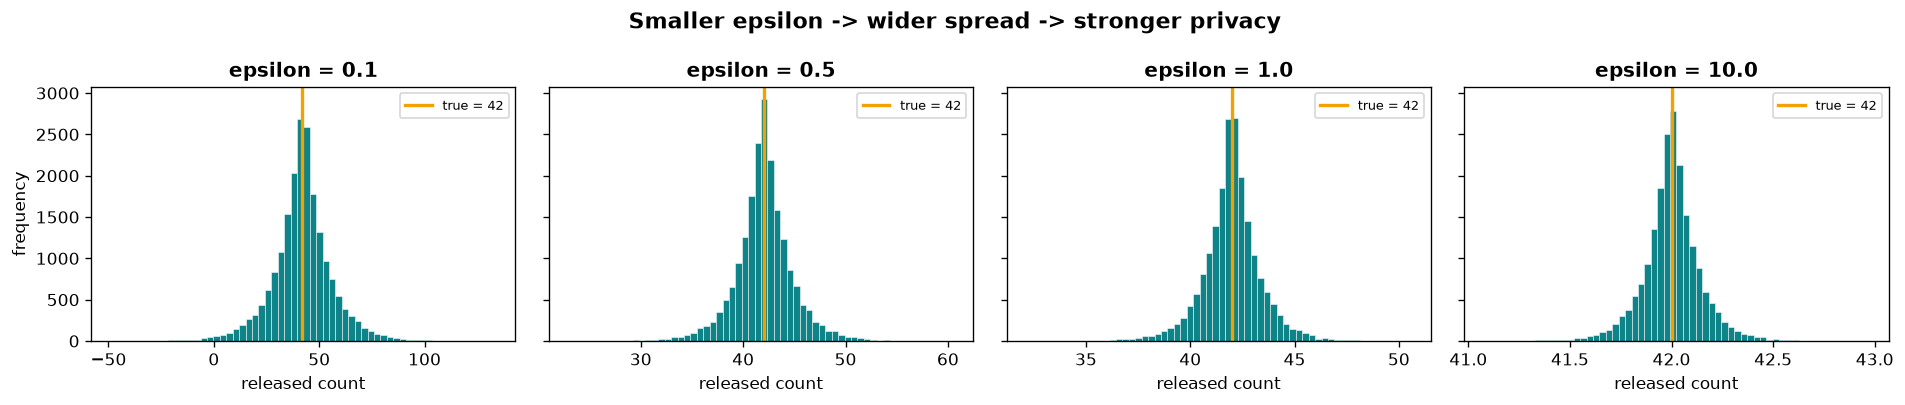

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.4), sharey=True)
for ax, eps in zip(axes, [0.1, 0.5, 1.0, 10.0]):
    draws = dp_count(TRUE_COUNT, eps)
    ax.hist(draws, bins=60, color="#0E8388", edgecolor="white", linewidth=0.3)
    ax.axvline(TRUE_COUNT, color="#F2A100", linewidth=2, label="true = 42")
    ax.set_title(f"epsilon = {eps}", fontsize=12, fontweight="bold")
    ax.set_xlabel("released count")
    ax.legend(fontsize=8)
axes[0].set_ylabel("frequency")
plt.suptitle("Smaller epsilon -> wider spread -> stronger privacy", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

The **privacy budget** is exactly that - a budget. Every query you answer about the same people spends some ε. Ask enough questions and the noise averages out, so DP systems track a running total and stop answering once the budget is exhausted.

### Exercises - Part 2

1. Add `epsilon = 0.5` to the loop and the plot. Where does its spread sit relative to the others?
2. A *sum* of salaries where the maximum salary is 100k has sensitivity 100000, not 1. Write `dp_sum(true_value, epsilon, sensitivity)` and try `epsilon = 1` with that sensitivity. Why is the result so noisy, and what does that tell you about querying unbounded quantities?
3. You have a total budget of ε = 1 and want to ask **five** count queries. If you split it evenly, what ε does each query get, and what happens to their accuracy?

---

## Bringing it back to your Data Management Plan

Section 3 of your DMP asks you to justify an anonymization approach. Use what you just ran:

- If you will **release a dataset**, state your target **k**, name the quasi-identifiers, and say how you will handle the l-diversity / t-closeness gap.
- If you will **release statistics or a model**, consider **differential privacy** and state the **epsilon** you would spend and why.
- Either way, record the **utility cost** - what precision you gave up to get the protection. That honest trade-off is exactly what a doctoral committee looks for.

*Production tools to explore next: ARX (arx.deidentifier.org) for k-anonymity and l-diversity on real tables; OpenDP, Tumult Analytics, or Google's DP library for differential privacy.*

In [10]:
# Completed exercises - Part 2

# 2) A bounded salary sum has high sensitivity, so useful privacy adds large noise.
def dp_sum(true_value, epsilon, sensitivity, seed=42):
    local_rng = np.random.default_rng(seed)
    return true_value + local_rng.laplace(0.0, sensitivity / epsilon)

salary_release = dp_sum(true_value=1_000_000, epsilon=1.0, sensitivity=100_000)
print(f"Exercise 2 - DP salary sum release: {salary_release:,.0f} (true value 1,000,000)")
print("The noise is large because one person's bounded contribution can change the sum by 100,000.")

# 3) Sequential composition divides the total privacy budget across queries.
total_budget = 1.0
queries = 5
epsilon_per_query = total_budget / queries
scale_per_query = SENSITIVITY / epsilon_per_query
print(f"Exercise 3 - epsilon per query = {epsilon_per_query:.1f}")
print(f"Each count query has Laplace scale = {scale_per_query:.1f}, so accuracy decreases.")


Exercise 2 - DP salary sum release: 1,079,388 (true value 1,000,000)
The noise is large because one person's bounded contribution can change the sum by 100,000.
Exercise 3 - epsilon per query = 0.2
Each count query has Laplace scale = 5.0, so accuracy decreases.
